# Importacion de librerias

In [1]:
!pip install -q visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import random
import time

import matplotlib.pyplot as plt
import seaborn as sns
import visualkeras

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, SimpleRNN, Bidirectional

from tensorflow.keras.callbacks import EarlyStopping

#Importacion de datos

In [3]:
df = pd.read_csv("dataset_egg_storage.csv", sep=";")

print("Dimensiones:", df.shape)

print("\nNúmero de huevos:")
print(df["sample"].nunique())

print("\nObservaciones por huevo:")
print(df.groupby("sample").size())

print("\nDías observados por huevo:")
display(
    df.groupby("sample")["storage_days"]
      .agg(["min","max","nunique"])
      .sort_index()
)

Dimensiones: (660, 333)

Número de huevos:
30

Observaciones por huevo:
sample
1     22
2     22
3     22
4     22
5     22
6     22
7     22
8     22
9     22
10    22
11    22
12    22
13    22
14    22
15    22
16    22
17    22
18    22
19    22
20    22
21    22
22    22
23    22
24    22
25    22
26    22
27    22
28    22
29    22
30    22
dtype: int64

Días observados por huevo:


,min,max,nunique
sample,,,
1,0,21,22
2,0,21,22
3,0,21,22
4,0,21,22
5,0,21,22
6,0,21,22
7,0,21,22
8,0,21,22
9,0,21,22


#Estadistica descriptiva

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
storage_days,660.0,10.500000,6.349101,0.00000,5.000000,10.500000,16.000000,21.00000
sample,660.0,15.500000,8.662006,1.00000,8.000000,15.500000,23.000000,30.00000
Spectra_740,660.0,0.688877,0.039544,0.51687,0.663560,0.690870,0.715490,0.79545
Spectra_741,660.0,0.689855,0.039527,0.51735,0.665085,0.692005,0.716673,0.79587
Spectra_742,660.0,0.690832,0.039519,0.51785,0.666073,0.693090,0.718003,0.79636
...,...,...,...,...,...,...,...,...
Spectra_1066,660.0,0.688185,0.043372,0.51656,0.661330,0.692420,0.717758,0.79157
Spectra_1067,660.0,0.687084,0.043343,0.51583,0.660315,0.691240,0.716505,0.79042
Spectra_1068,660.0,0.684808,0.043236,0.51418,0.658098,0.688990,0.714085,0.78791
Spectra_1069,660.0,0.682032,0.043094,0.51214,0.655405,0.686245,0.711155,0.78485


#Distribucion de la variable objetivo

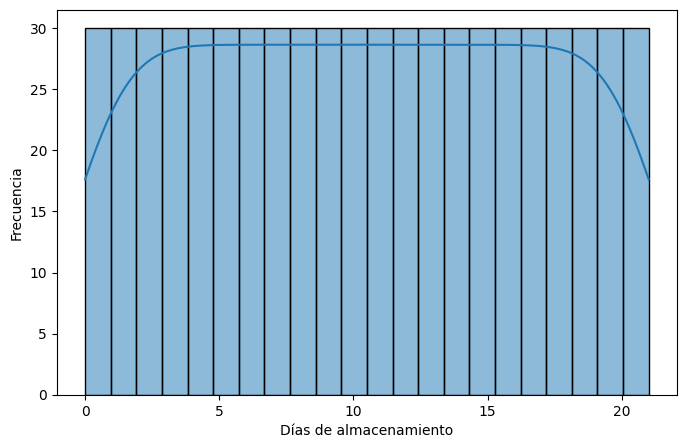

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["storage_days"],
    bins=22,
    kde=True
)

plt.xlabel("Días de almacenamiento")
plt.ylabel("Frecuencia")
plt.show()

#Boxplot de la respuesta

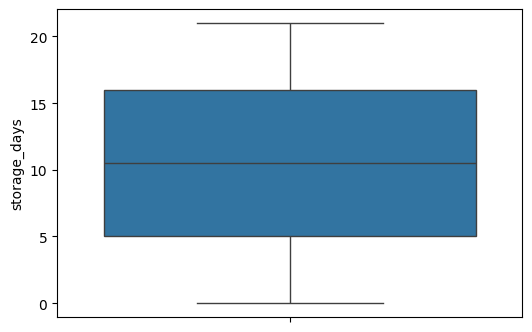

In [6]:
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["storage_days"]
)

plt.show()

#Espectros individuales

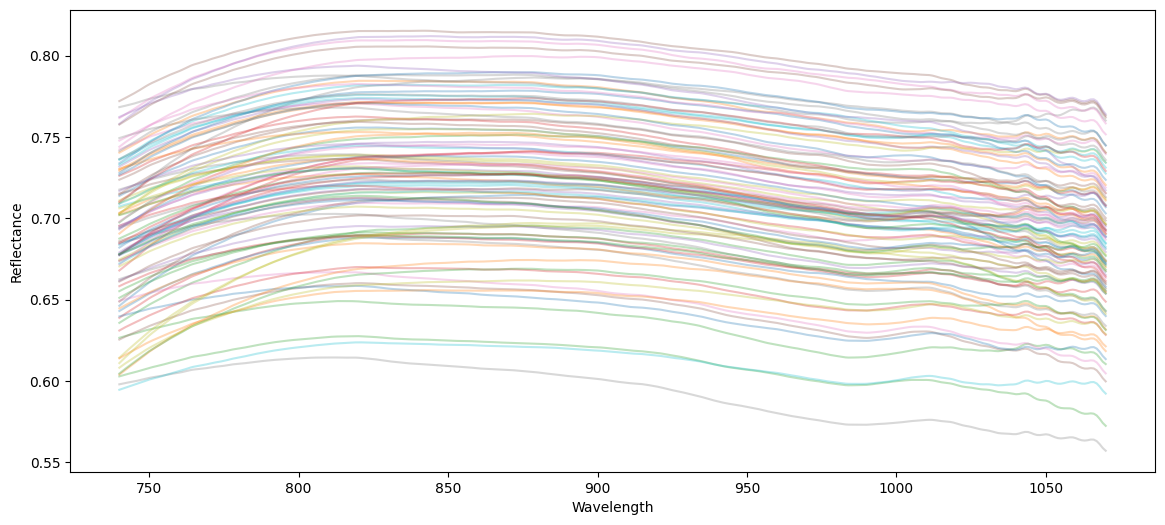

In [7]:
spectral_cols = [
    c for c in df.columns
    if c.startswith("Spectra_")
]

wavelengths = [
    int(c.split("_")[1])
    for c in spectral_cols
]

plt.figure(figsize=(14,6))

for i in range(100):
    plt.plot(
        wavelengths,
        df.loc[i, spectral_cols],
        alpha=0.3
    )

plt.xlabel("Wavelength")
plt.ylabel("Reflectance")
plt.show()

#Espectro promedio

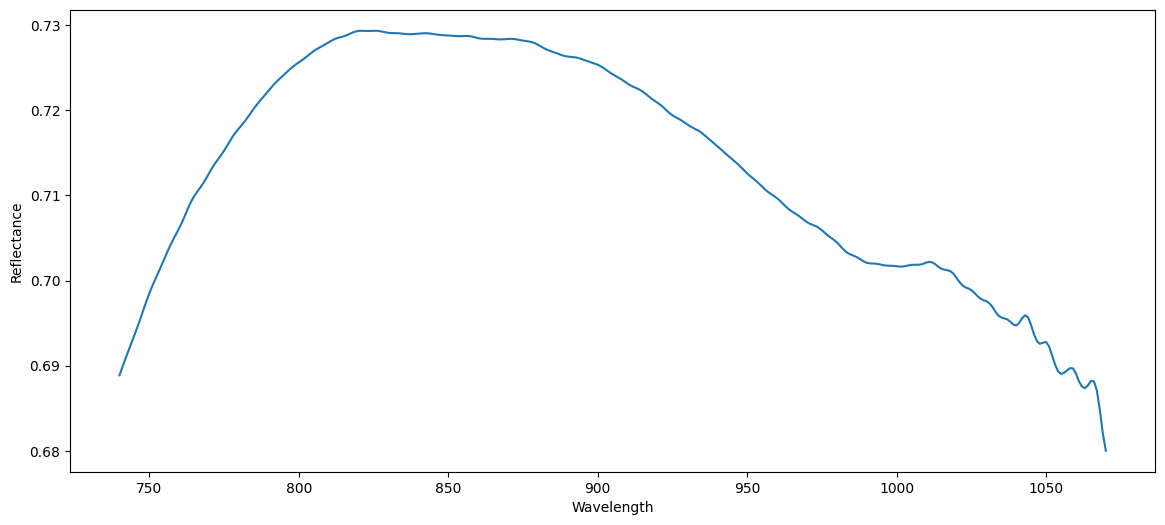

In [8]:
mean_spectrum = df[spectral_cols].mean()

plt.figure(figsize=(14,6))

plt.plot(
    wavelengths,
    mean_spectrum
)

plt.xlabel("Wavelength")
plt.ylabel("Reflectance")
plt.show()

#PCA exploratorio

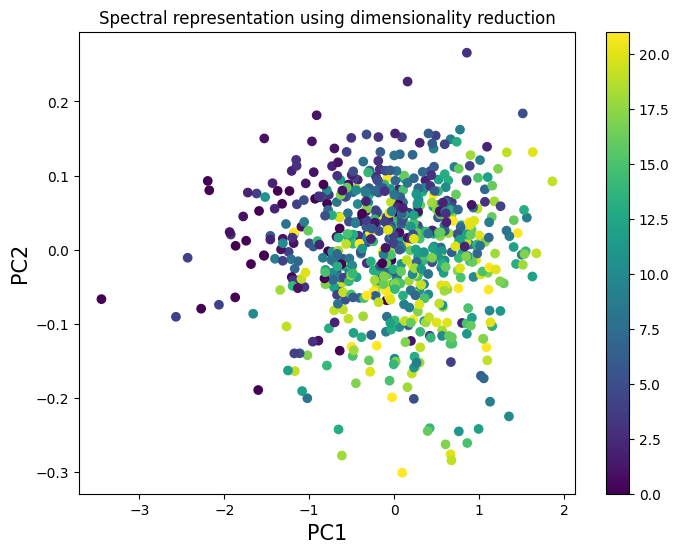

In [9]:
X = df[spectral_cols]

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["storage_days"],
    cmap="viridis"
)

plt.colorbar(scatter)

plt.xlabel("PC1", fontsize=15)
plt.ylabel("PC2", fontsize=15)

plt.title('Spectral representation using dimensionality reduction')

plt.show()

#Division entrenamiento/prueba

In [10]:
SEED = 42
EPOCHS = 300

spectrum = df.drop(['storage_days', 'sample'], axis=1)
y = df['storage_days']

X_train, X_test, y_train, y_test = train_test_split(spectrum, y, test_size=0.2, random_state=SEED)

#Modelo ANN base

In [11]:
ann = Sequential()

ann.add(Input(shape=(X_train.shape[1],)))

ann.add(Dense(128, activation="relu"))
ann.add(Dropout(0.2))

ann.add(Dense(64, activation="relu"))
ann.add(Dropout(0.2))

ann.add(Dense(1, activation='linear'))

ann.summary()

ann.compile(optimizer="adam", loss="mse", metrics=["mae"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,817 (198.50 KB)

 Trainable params: 50,817 (198.50 KB)

 Non-trainable params: 0 (0.00 B)

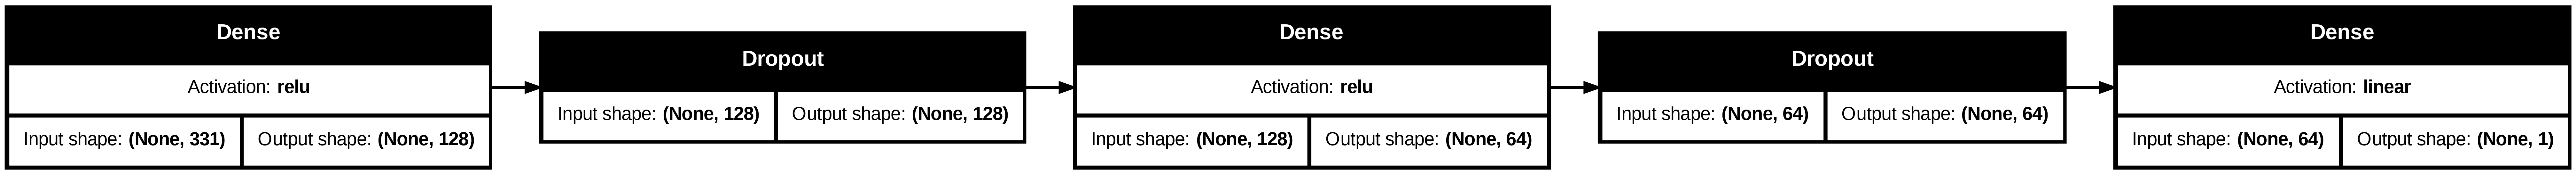

In [12]:
plot_model(ann, 'ANN_model.png',
           show_shapes=True,
          #  show_layer_names=True,
           expand_nested=True,
           show_layer_activations=True,
           rankdir='LR',
           dpi=300)

##Entrenamiento ANN

In [13]:
early_stop = EarlyStopping(
    patience=20,
    restore_best_weights=True
)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

inicio = time.time()


history_ann = ann.fit(X_train, y_train, epochs=EPOCHS, batch_size=32,
                      validation_split=0.2, callbacks=[early_stop],
                      verbose=1)

fin = time.time()

print('Tiempo de entrenamiento:', fin - inicio, 'segundos', sep=' ')

Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 64.9177 - mae: 6.5487 - val_loss: 55.1011 - val_mae: 6.1946
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 46.0661 - mae: 5.7030 - val_loss: 35.5892 - val_mae: 5.1285
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 41.3178 - mae: 5.5508 - val_loss: 38.8102 - val_mae: 5.4072
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 43.7936 - mae: 5.6938 - val_loss: 35.6952 - val_mae: 5.1845
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 40.1273 - mae: 5.4219 - val_loss: 37.1649 - val_mae: 5.3033
Epoch 6/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 43.2887 - mae: 5.6444 - val_loss: 35.8103 - val_mae: 5.1939
Epoch 7/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 42.5166 - mae: 5.5371 - val_loss: 36.5641 - val_mae: 5.2556
Epoch 8/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 42.9605 - mae: 5.6203 - val_loss: 35.9692 - val_mae: 5.2075
Epoch 9/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1

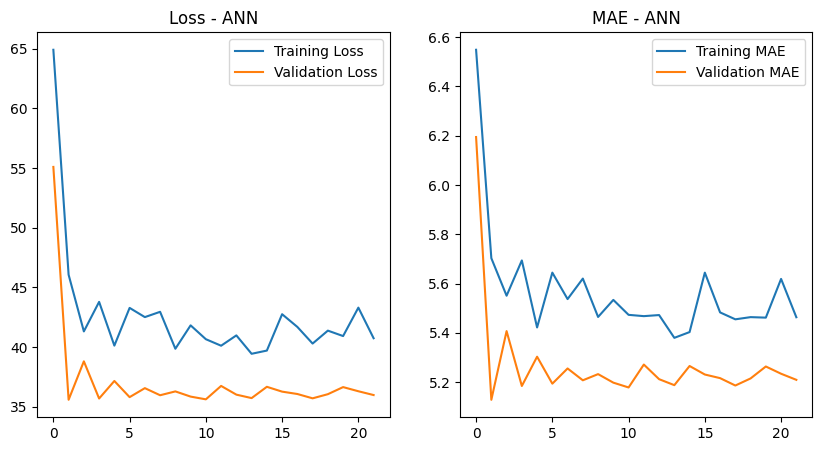

In [14]:
ann_loss = history_ann.history.get('loss')
ann_val_loss = history_ann.history.get('val_loss')
ann_mae = history_ann.history.get('mae')
ann_val_mae = history_ann.history.get('val_mae')

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history_ann.epoch, ann_loss, label='Training Loss')
plt.plot(history_ann.epoch, ann_val_loss, label='Validation Loss')
plt.title('Loss - ANN')

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ann.epoch, ann_mae, label='Training MAE')
plt.plot(history_ann.epoch, ann_val_mae, label='Validation MAE')
plt.title('MAE - ANN')

plt.legend()

plt.show()

##Evaluacion de ANN en Train

In [15]:
print('Evaluacion del modelo ANN en TRAIN')

pred_train_ann = ann.predict(X_train)

print("R2:", r2_score(y_train,pred_train_ann))

print("MAE:", mean_absolute_error(y_train, pred_train_ann))

print("RMSE:", np.sqrt(mean_squared_error(y_train, pred_train_ann)))

# print("MAPE:", mean_absolute_percentage_error(y_train, pred_train_ann))

Evaluacion del modelo ANN en TRAIN
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R2: 0.022671639919281006
MAE: 5.414988040924072
RMSE: 6.283062573711628


##Evaluacion de ANN en Test

In [16]:
print('Evaluacion del modelo ANN en TRAIN')

pred_test_ann = ann.predict(X_test)

print("R2:", r2_score(y_test, pred_test_ann))

print("MAE:", mean_absolute_error(y_test, pred_test_ann))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_ann)))

Evaluacion del modelo ANN en TRAIN
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
R2: 0.005584239959716797
MAE: 5.361817359924316
RMSE: 6.279497044340638


#Modelo RNN

In [17]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(64,activation="tanh",input_shape=(X_train.shape[1],1)))
rnn_model.add(Dropout(0.20))
rnn_model.add(Dense(32,activation="relu"))
rnn_model.add(Dense(1, activation='linear'))

rnn_model.compile(optimizer="adam",loss="mse", metrics=["mae"])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

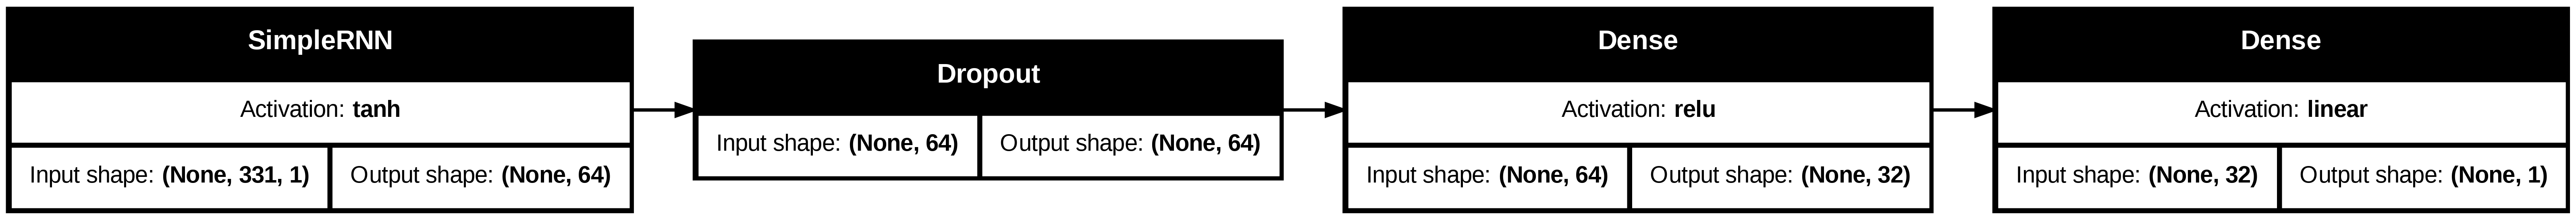

In [18]:
plot_model(rnn_model, 'RNN_model.png',
           show_shapes=True,
          #  show_layer_names=True,
           expand_nested=True,
           show_layer_activations=True,
           rankdir='LR',
           dpi=300)

##Entrenamiento RNN

In [19]:
early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

inicio = time.time()
history_rnn = rnn_model.fit(X_train,y_train, validation_split=0.20, epochs=EPOCHS,
                            batch_size=16, callbacks=[early_stop], verbose=1)

fin = time.time()

print('Tiempo de entrenamiento:', fin - inicio, 'segundos', sep=' ')

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 81.1942 - mae: 7.3445 - val_loss: 40.5182 - val_mae: 5.5148
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 43.6346 - mae: 5.6673 - val_loss: 39.2040 - val_mae: 5.4285
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 41.3349 - mae: 5.5570 - val_loss: 40.2204 - val_mae: 5.4971
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 40.7604 - mae: 5.5112 - val_loss: 39.8445 - val_mae: 5.4742
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 40.4536 - mae: 5.4873 - val_loss: 39.8499 - val_mae: 5.4746
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 41.0664 - mae: 5.5515 - val_loss: 39.8188 - val_mae: 5.4726
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 41.8259 - mae: 5.5698 - val_loss: 39.6316 - val_mae: 5.4604
Epoch 8/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 41.7538 - mae: 5.6003 - val_loss: 39.7782 - val_mae: 5.4701
Epoch 9/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 2

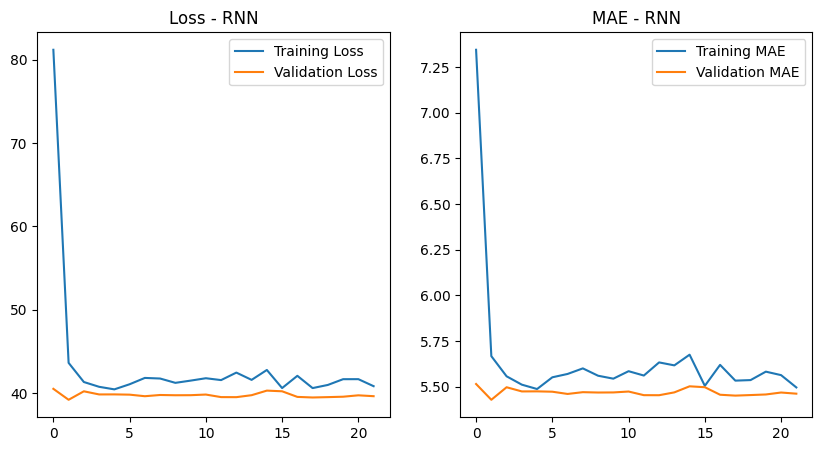

In [20]:
rnn_loss = history_rnn.history.get('loss')
rnn_val_loss = history_rnn.history.get('val_loss')
rnn_mae = history_rnn.history.get('mae')
rnn_val_mae = history_rnn.history.get('val_mae')

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.epoch, rnn_loss, label='Training Loss')
plt.plot(history_rnn.epoch, rnn_val_loss, label='Validation Loss')
plt.title('Loss - RNN')

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.epoch, rnn_mae, label='Training MAE')
plt.plot(history_rnn.epoch, rnn_val_mae, label='Validation MAE')
plt.title('MAE - RNN')

plt.legend()

plt.show()

## Evaluacion de RNN en train

In [21]:
print('Evaluacion del modelo RNN en TRAIN')

pred_train_rnn = rnn_model.predict(X_train)

print("R2:", r2_score(y_train,pred_train_rnn))

print("MAE:", mean_absolute_error(y_train, pred_train_rnn))

print("RMSE:", np.sqrt(mean_squared_error(y_train, pred_train_rnn)))

Evaluacion del modelo RNN en TRAIN
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
R2: 0.0013313889503479004
MAE: 5.516904354095459
RMSE: 6.351288624169114


## Evaluacion de RNN en Test

In [22]:
print('Evaluacion del modelo RNN en TRAIN')

pred_test_rnn = rnn_model.predict(X_test)

print("R2:", r2_score(y_test, pred_test_rnn))

print("MAE:", mean_absolute_error(y_test, pred_test_rnn))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_rnn)))

Evaluacion del modelo RNN en TRAIN
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
R2: 0.000989675521850586
MAE: 5.414256572723389
RMSE: 6.293987359852761


 # Modelo LSTM

In [23]:
lstm_model = Sequential()

lstm_model.add(LSTM(128,return_sequences=True,input_shape=(X_train.shape[1],1)))
lstm_model.add(Dropout(0.20))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(32,activation="relu"))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam",loss="mse",metrics=["mae"])

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 331, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 331, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

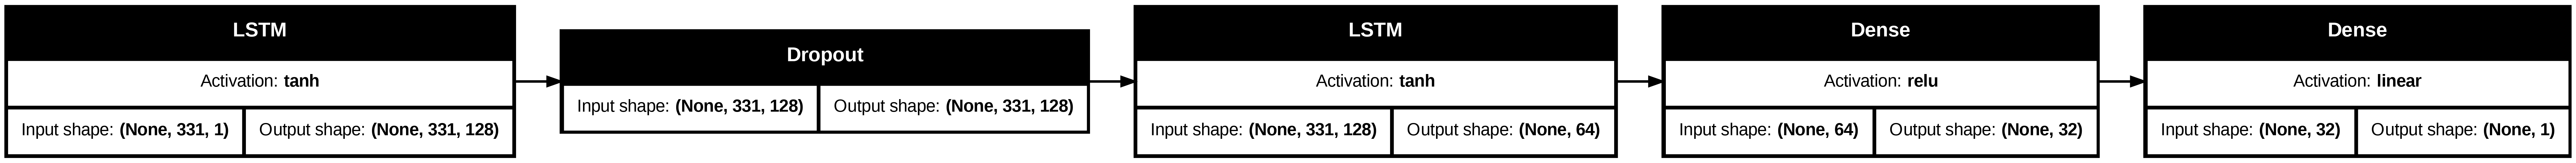

In [24]:
plot_model(lstm_model, 'LSTM_model.png',
           show_shapes=True,
          #  show_layer_names=True,
           expand_nested=True,
           show_layer_activations=True,
           rankdir='LR',
           dpi=300)

##Entrenamiento LSTM

In [25]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

inicio = time.time()
history_lstm = lstm_model.fit(X_train, y_train, validation_split=0.20,
                              epochs=EPOCHS, callbacks=[early_stop], verbose=1)
fin = time.time()

print('Tiempo de entrenamiento:', fin - inicio, 'segundos', sep=' ')

Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 657ms/step - loss: 128.1003 - mae: 9.4980 - val_loss: 63.9535 - val_mae: 6.3952
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 659ms/step - loss: 57.8985 - mae: 6.3110 - val_loss: 38.1571 - val_mae: 5.3083
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 537ms/step - loss: 40.5600 - mae: 5.5442 - val_loss: 42.9775 - val_mae: 5.6390
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 545ms/step - loss: 41.5903 - mae: 5.5637 - val_loss: 41.3209 - val_mae: 5.5603
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 664ms/step - loss: 40.9152 - mae: 5.5362 - val_loss: 39.7363 - val_mae: 5.4666
Epoch 6/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 701ms/step - loss: 40.6826 - mae: 5.5361 - val_loss: 39.8074 - val_mae: 5.4714
Epoch 7/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 537ms/step - loss: 40.6951 - mae: 5.5323 - val_loss: 40.1576 - val_mae: 5.4934
Epoch 8/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 684ms/step - loss: 40.7106 - mae: 5.5273 - val_loss: 40.1507 - val_mae: 5.4930
Epoch 9/300
14/14 ━━━━━━━━━

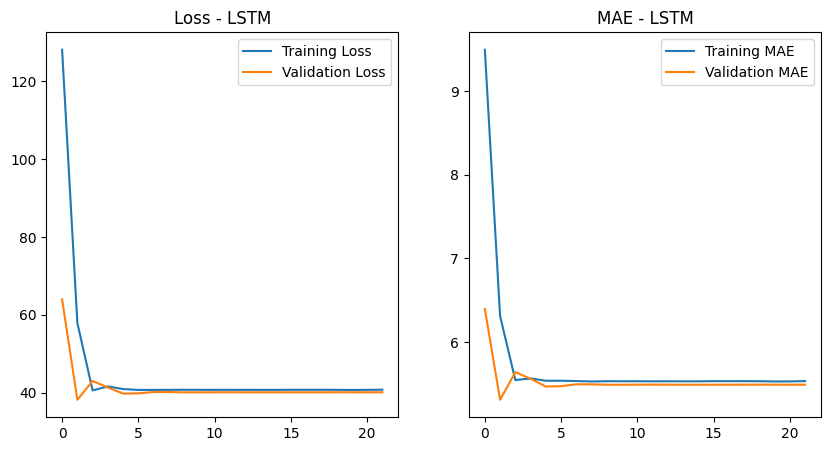

In [26]:
lstm_loss = history_lstm.history.get('loss')
lstm_val_loss = history_lstm.history.get('val_loss')
lstm_mae = history_lstm.history.get('mae')
lstm_val_mae = history_lstm.history.get('val_mae')

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.epoch, lstm_loss, label='Training Loss')
plt.plot(history_lstm.epoch, lstm_val_loss, label='Validation Loss')
plt.title('Loss - LSTM')

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.epoch, lstm_mae, label='Training MAE')
plt.plot(history_lstm.epoch, lstm_val_mae, label='Validation MAE')
plt.title('MAE - LSTM')

plt.legend()

plt.show()

## Evaluacion LSTM en Train

In [27]:
print('Evaluacion del modelo LSTM en TRAIN')

pred_train_lstm = lstm_model.predict(X_train)

print("R2:", r2_score(y_train, pred_train_lstm))

print("MAE:", mean_absolute_error(y_train, pred_train_lstm))

print("RMSE:", np.sqrt(mean_squared_error(y_train, pred_train_lstm)))

Evaluacion del modelo LSTM en TRAIN
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step
R2: -0.025635361671447754
MAE: 5.5711493492126465
RMSE: 6.436468541740755


##Evaluacion LSTM en Test

In [28]:
print('Evaluacion del modelo RNN en TRAIN')

pred_test_lstm = lstm_model.predict(X_test)

print("R2:", r2_score(y_test, pred_test_lstm))

print("MAE:", mean_absolute_error(y_test, pred_test_lstm))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_lstm)))

Evaluacion del modelo RNN en TRAIN
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step
R2: -0.03616774082183838
MAE: 5.466991424560547
RMSE: 6.409968790106292


# Modelo Bi-LSTM

In [29]:
bilstm_model = Sequential()
bilstm_model.add(Bidirectional(LSTM(128,return_sequences=True),input_shape=(X_train.shape[1],1)))
bilstm_model.add(Dropout(0.20))
bilstm_model.add(Bidirectional(LSTM(64)))
bilstm_model.add(Dense(32,activation="relu"))
bilstm_model.add(Dense(1))

bilstm_model.summary()

bilstm_model.compile(optimizer="adam",loss="mse",metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 331, 256)       │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 331, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,633 (1.15 MB)

 Trainable params: 301,633 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

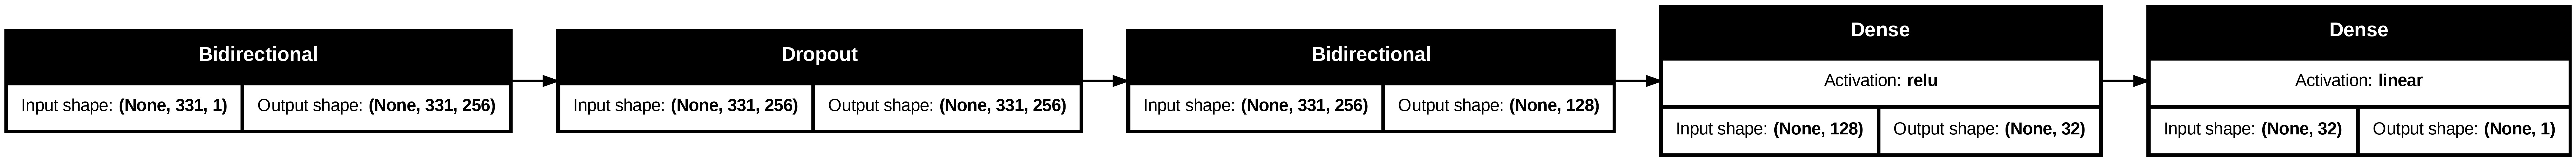

In [30]:
plot_model(bilstm_model, 'BILSTM_model.png',
           show_shapes=True,
          #  show_layer_names=True,
           expand_nested=True,
           show_layer_activations=True,
           rankdir='LR',
           dpi=300)

##Entrenamiento Bi-LSTM

In [31]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

inicio = time.time()
history_bilstm = bilstm_model.fit(X_train, y_train, validation_split=0.20,
                                  epochs=EPOCHS, callbacks=[early_stop], verbose=1)

fin = time.time()
print('Tiempo de entrenamiento:', fin - inicio, 'segundos', sep=' ')

Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 106.1886 - mae: 8.4590 - val_loss: 39.3811 - val_mae: 5.3175
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 41.4842 - mae: 5.5885 - val_loss: 45.9975 - val_mae: 5.7750
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 41.9484 - mae: 5.5671 - val_loss: 38.9226 - val_mae: 5.4022
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 40.6489 - mae: 5.5430 - val_loss: 40.2178 - val_mae: 5.4970
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 40.8015 - mae: 5.5273 - val_loss: 40.3762 - val_mae: 5.5062
Epoch 6/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 40.7725 - mae: 5.5332 - val_loss: 39.9046 - val_mae: 5.4778
Epoch 7/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 40.7290 - mae: 5.5332 - val_loss: 40.1916 - val_mae: 5.4954
Epoch 8/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 40.6971 - mae: 5.5251 - val_loss: 40.1003 - val_mae: 5.4900
Epoch 9/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/s

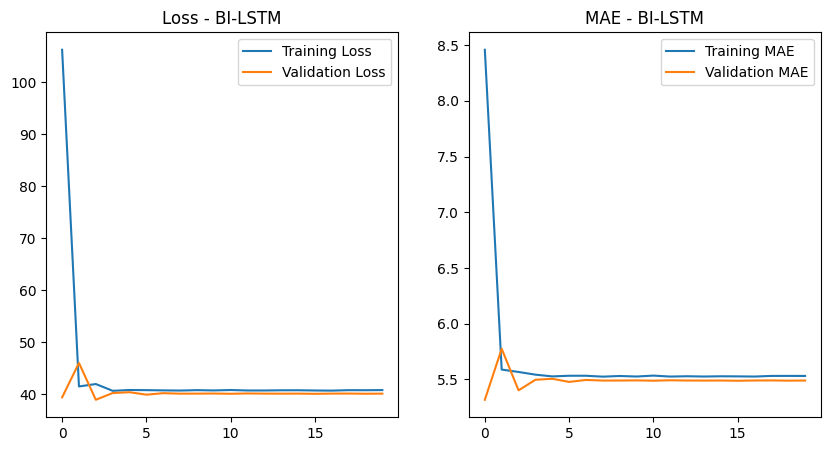

In [32]:
bilstm_loss = history_bilstm.history.get('loss')
bilstm_val_loss = history_bilstm.history.get('val_loss')
bilstm_mae = history_bilstm.history.get('mae')
bilstm_val_mae = history_bilstm.history.get('val_mae')

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history_bilstm.epoch, bilstm_loss, label='Training Loss')
plt.plot(history_bilstm.epoch, bilstm_val_loss, label='Validation Loss')
plt.title('Loss - BI-LSTM')

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_bilstm.epoch, bilstm_mae, label='Training MAE')
plt.plot(history_bilstm.epoch, bilstm_val_mae, label='Validation MAE')
plt.title('MAE - BI-LSTM')

plt.legend()

plt.show()

## Evaluacion de BI-LSTM en Train

In [33]:
print('Evaluacion del modelo LSTM en Test')

pred_train_bilstm = bilstm_model.predict(X_train)

print("R2:", r2_score(y_train, pred_train_bilstm))

print("MAE:", mean_absolute_error(y_train, pred_train_bilstm))

print("RMSE:", np.sqrt(mean_squared_error(y_train, pred_train_bilstm)))

Evaluacion del modelo LSTM en Test
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 410ms/step
R2: -0.10737335681915283
MAE: 5.714564800262451
RMSE: 6.688029330686656


## Evaluacion de BI-LSTM en test

In [34]:
print('Evaluacion del modelo RNN en Test')

pred_test_lstm = lstm_model.predict(X_test)

print("R2:", r2_score(y_test, pred_test_lstm))

print("MAE:", mean_absolute_error(y_test, pred_test_lstm))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_lstm)))

Evaluacion del modelo RNN en Test
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step
R2: -0.03616774082183838
MAE: 5.466991424560547
RMSE: 6.409968790106292


# Grafico general de entrenamientos

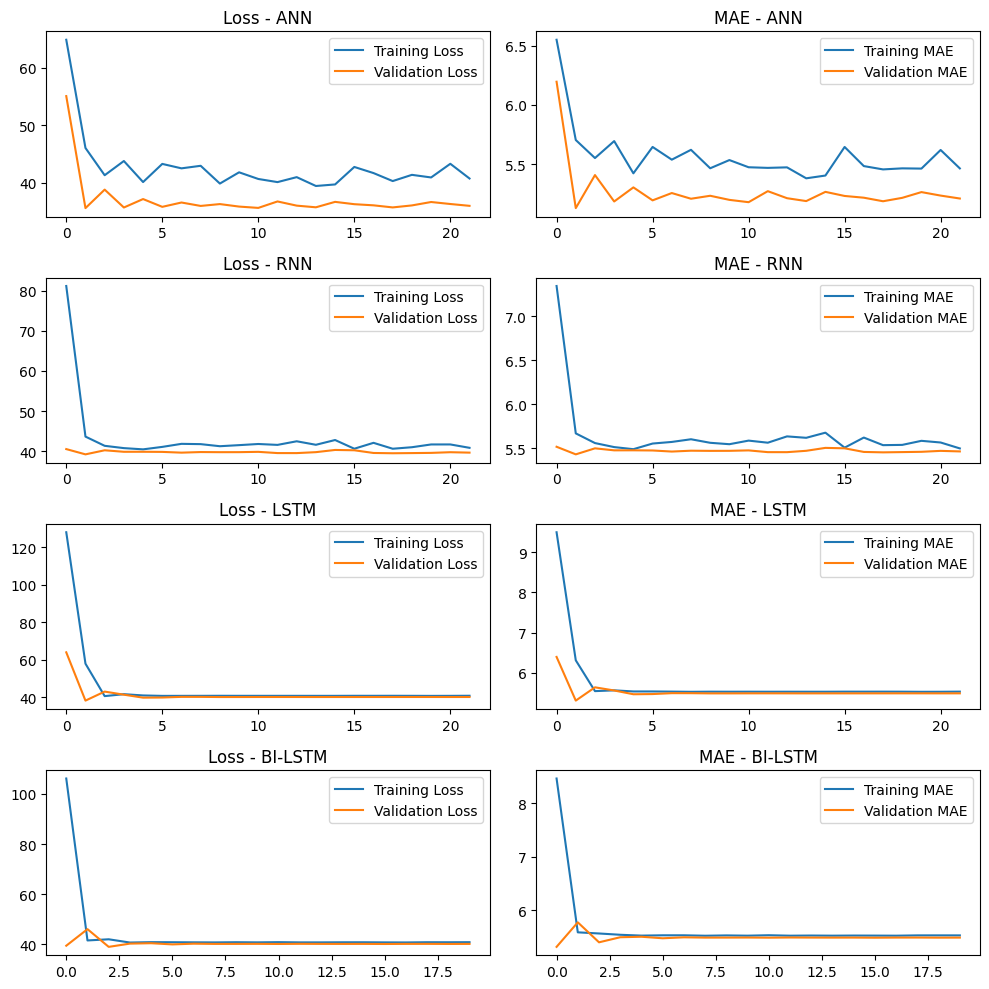

In [35]:
plt.figure(figsize=(10, 10))

plt.subplot(4, 2, 1)
plt.plot(history_ann.epoch, ann_loss, label='Training Loss')
plt.plot(history_ann.epoch, ann_val_loss, label='Validation Loss')
plt.title('Loss - ANN')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(history_ann.epoch, ann_mae, label='Training MAE')
plt.plot(history_ann.epoch, ann_val_mae, label='Validation MAE')
plt.title('MAE - ANN')
plt.legend()

plt.subplot(4, 2, 3)
plt.plot(history_rnn.epoch, rnn_loss, label='Training Loss')
plt.plot(history_rnn.epoch, rnn_val_loss, label='Validation Loss')
plt.title('Loss - RNN')
plt.legend()

plt.subplot(4, 2, 4)
plt.plot(history_rnn.epoch, rnn_mae, label='Training MAE')
plt.plot(history_rnn.epoch, rnn_val_mae, label='Validation MAE')
plt.title('MAE - RNN')
plt.legend()

plt.subplot(4, 2, 5)
plt.plot(history_lstm.epoch, lstm_loss, label='Training Loss')
plt.plot(history_lstm.epoch, lstm_val_loss, label='Validation Loss')
plt.title('Loss - LSTM')
plt.legend()

plt.subplot(4, 2, 6)
plt.plot(history_lstm.epoch, lstm_mae, label='Training MAE')
plt.plot(history_lstm.epoch, lstm_val_mae, label='Validation MAE')
plt.title('MAE - LSTM')
plt.legend()

plt.subplot(4, 2, 7)
plt.plot(history_bilstm.epoch, bilstm_loss, label='Training Loss')
plt.plot(history_bilstm.epoch, bilstm_val_loss, label='Validation Loss')
plt.title('Loss - BI-LSTM')
plt.legend()

plt.subplot(4, 2, 8)
plt.plot(history_bilstm.epoch, bilstm_mae, label='Training MAE')
plt.plot(history_bilstm.epoch, bilstm_val_mae, label='Validation MAE')
plt.title('MAE - BI-LSTM')
plt.legend()

plt.tight_layout()

plt.show()